# King Air B-200 calibration from NASA ICARTT field campaigns

Calibrates `KingAirB200()` from public NASA ICARTT (.ict) airborne
in-situ data across multiple field campaigns.  Source folders under
`data/KingAirB200/` (and the mislabeled `data/KingAirA90/BlueFlux_A90_AIMMS20/`
which the ICT metadata identifies as B-200 platform):

* ACTAMERICA — NASA LaRC B-200 housekeeping data, 2016-2020 (~176 files)
* DISCOVER-AQ California / Colorado / Texas — APPLANIX nav (~90 files)
* KORUS-AQ — B-200 NAV (~28 files)
* LMOS — UC-12 (B-200 military variant) NAV (~27 files)
* BlueFlux — AIMMS-20 in-situ wind probe (~38 files)
* ACTIVATE — METNAV; not used (only GPS altitude + heading, no TAS)

Each campaign uses a different ICARTT column-name convention; the
loader (`hyplan.aircraft.icartt.load_icartt`) maps them to a
canonical IWG1-style schema so the rest of the pipeline matches the
other calibration notebooks.


In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from hyplan import ureg
from hyplan.aircraft import KingAirB200
from hyplan.aircraft.icartt import load_icartt, detect_platform
from hyplan.aircraft.iwg1 import trim_ground_taxi  # works on the canonical-schema DataFrame

# Campaign directories to ingest.  Each .ict file in these dirs
# becomes one candidate sortie.  Folders mislabeled as A-90 are
# included where their ICT metadata identifies them as B-200.
CAMPAIGN_DIRS = [
    Path("../../../data/KingAirB200/ACTAMERICA_B200_Hskping").resolve(),
    Path("../../../data/KingAirB200/DISCOVERAQ_California_B200_APPLANIX").resolve(),
    Path("../../../data/KingAirB200/DISCOVERAQ_Colorado_B200_APPLANIX").resolve(),
    Path("../../../data/KingAirB200/DISCOVERAQ_Texas_B200_APPLANIX").resolve(),
    Path("../../../data/KingAirB200/KORUSAQ_B200_NAV").resolve(),
    Path("../../../data/KingAirB200/LMOS_UC12_NAV").resolve(),
    Path("../../../data/KingAirA90/BlueFlux_A90_AIMMS20").resolve(),  # ICT says B-200
]

# Phase-label thresholds (same as other calibration notebooks).
CLIMB_FPM   = 300.0
DESCENT_FPM = -300.0

# Sortie filters.
MIN_DUR_MIN     = 60.0
MAX_DUR_MIN     = 600.0
MIN_PEAK_ALT_FT = 8000   # B-200 cruises FL150-FL280 typically; some
                         # boundary-layer campaigns peak around FL080
                         # (real flights, not test/abort)
MAX_PEAK_ALT_FT = 35000  # B-200 brochure ceiling


## 1. Load + phase-label every sortie

In [2]:
def label_phases(df, climb_fpm=CLIMB_FPM, descent_fpm=DESCENT_FPM):
    out = df.copy()
    vs = out["vertical_rate"].to_numpy()
    phase = np.full(len(out), "unlabeled", dtype=object)
    phase[vs >  climb_fpm]   = "climb"
    phase[vs <  descent_fpm] = "descent"
    phase[(vs >= descent_fpm) & (vs <= climb_fpm)] = "cruise"
    out["phase"] = phase
    return out


sorties = {}
skipped = []
for cdir in CAMPAIGN_DIRS:
    if not cdir.is_dir():
        continue
    for p in sorted(cdir.glob("*.ict")):
        try:
            raw = load_icartt(p)
        except Exception as e:
            skipped.append((p.stem, f"load failed ({type(e).__name__})"))
            continue
        # Try standard groundspeed-based trim first; fall back to
        # altitude-only when groundspeed is missing from the ICT.
        if raw["groundspeed"].notna().sum() > 100:
            a = trim_ground_taxi(raw)
        else:
            alt = raw["altitude"]
            if alt.dropna().empty:
                skipped.append((p.stem, "no airborne fixes"))
                continue
            airborne = (alt - alt.min()) > 200
            if not airborne.any():
                skipped.append((p.stem, "no airborne fixes"))
                continue
            first = int(airborne.values.argmax())
            last = int(len(airborne) - 1 - airborne.values[::-1].argmax())
            a = raw.iloc[first:last + 1].reset_index(drop=True)
        if a.empty:
            skipped.append((p.stem, "no airborne fixes"))
            continue
        a = a.dropna(subset=["altitude", "vertical_rate"]).reset_index(drop=True)
        if a.empty:
            skipped.append((p.stem, "no valid altitude"))
            continue
        dur_min = (a["timestamp"].iloc[-1] - a["timestamp"].iloc[0]).total_seconds() / 60.0
        peak = a["altitude"].max()
        if dur_min < MIN_DUR_MIN:
            skipped.append((p.stem, f"too short ({dur_min:.0f} min)"))
            continue
        if dur_min > MAX_DUR_MIN:
            skipped.append((p.stem, f"too long ({dur_min:.0f} min)"))
            continue
        if peak < MIN_PEAK_ALT_FT:
            skipped.append((p.stem, f"low peak alt ({peak:.0f} ft)"))
            continue
        if peak > MAX_PEAK_ALT_FT:
            skipped.append((p.stem, f"high peak alt ({peak:.0f} ft) — not a B-200"))
            continue
        sorties[p.stem] = label_phases(a)

print(f"loaded {len(sorties)} valid sorties")
print(f"skipped {len(skipped)} files (filter reasons summarized below)")
print()
from collections import Counter
reasons = Counter(r.split(' (')[0] for _, r in skipped)
for reason, n in reasons.most_common():
    print(f"  {n:4d}  {reason}")


loaded 272 valid sorties
skipped 79 files (filter reasons summarized below)

    53  no airborne fixes
    19  low peak alt
     7  too short


## 2. Per-sortie altitude profiles

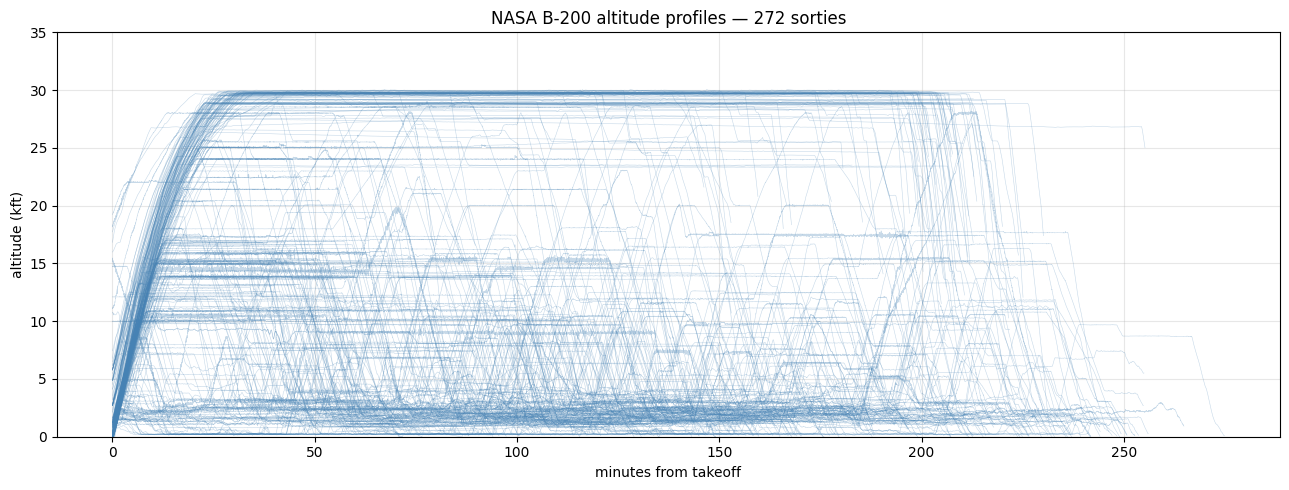

In [3]:
fig, ax = plt.subplots(figsize=(13, 5))
for name, a in sorties.items():
    t_min = (a["timestamp"] - a["timestamp"].iloc[0]).dt.total_seconds() / 60.0
    ax.plot(t_min, a["altitude"] / 1000, lw=0.4, alpha=0.3, color="steelblue")
ax.set_xlabel("minutes from takeoff")
ax.set_ylabel("altitude (kft)")
ax.set_title(f"NASA B-200 altitude profiles — {len(sorties)} sorties")
ax.grid(alpha=0.3)
ax.set_ylim(0, 35)
plt.tight_layout(); plt.show()


## 3. Climb / descent: per-altitude-bin medians

In [4]:
# B-200 climb rates drop below 1500 fpm above FL150; lowering
# the active threshold to 1000 fpm extends climb-bin coverage
# through FL200-FL280.  Same trade-off as the Twin Otter
# (where the threshold is 800 fpm).
ACTIVE_VS_THR_FPM = 1000.0
BIN_FT = 5000


def per_bin(phase, sign):
    rows = []
    for a in sorties.values():
        sub = a[a["phase"] == phase]
        sub = sub[(sub["vertical_rate"] * sign) >= ACTIVE_VS_THR_FPM]
        rows.append(sub[["altitude", "vertical_rate", "tas_kt", "roll_deg"]].copy())
    df = pd.concat(rows).dropna(subset=["altitude"])
    df["alt_bin_ft"] = (df["altitude"] // BIN_FT * BIN_FT).astype(int)
    g = df.groupby("alt_bin_ft").agg(
        n=("vertical_rate", "count"),
        vs_med=("vertical_rate", "median"),
        vs_p25=("vertical_rate", lambda x: x.quantile(0.25)),
        vs_p75=("vertical_rate", lambda x: x.quantile(0.75)),
        tas_med=("tas_kt", "median"),
    ).round(1).reset_index()
    return g[g["n"] >= 30]


climb_bins = per_bin("climb", sign=+1)
descent_bins = per_bin("descent", sign=-1)
print("Active CLIMB:");   print(climb_bins.to_string(index=False))
print()
print("Active DESCENT:"); print(descent_bins.to_string(index=False))


Active CLIMB:
 alt_bin_ft      n  vs_med  vs_p25  vs_p75  tas_med
      -5000    392  1396.2  1296.7  1607.5    129.8
          0 163058  1266.8  1144.6  1448.2    143.8
       5000 172694  1319.7  1163.5  1544.1    157.9
      10000  64197  1346.0  1202.4  1494.5    191.3
      15000  48182  1190.4  1099.6  1297.4    199.1
      20000  10700  1068.0  1031.2  1129.4    198.7
      25000    215  1030.7  1012.8  1060.5    196.1

Active DESCENT:
 alt_bin_ft      n  vs_med  vs_p25  vs_p75  tas_med
          0  83170 -1197.9 -1356.7 -1085.6    182.0
       5000 108798 -1319.8 -1505.9 -1136.0    206.3
      10000  30893 -1397.3 -1767.8 -1185.9    226.7
      15000  21869 -1551.1 -2212.3 -1232.1    245.2
      20000  21212 -1852.1 -2559.7 -1343.4    260.2
      25000  18099 -1405.6 -1813.6 -1200.7    264.4


## 4. climb_profile / descent_profile breakpoints (per-bin medians)

In [5]:
fixed = []
for _, r in climb_bins.iterrows():
    if 0 <= r["alt_bin_ft"] < 35000:
        fixed.append((int(r["alt_bin_ft"]), float(r["vs_med"])))
fixed.append((35000, 500))

fixed_desc = []
for _, r in descent_bins.iterrows():
    if 0 <= r["alt_bin_ft"] < 35000:
        fixed_desc.append((int(r["alt_bin_ft"]), abs(float(r["vs_med"]))))

print("climb_profile:")
for alt, vs in fixed:
    print(f"  ({alt:>5d}, {vs:6.0f})")
print()
print("descent_profile:")
for alt, vs in fixed_desc:
    print(f"  ({alt:>5d}, {vs:6.0f})")


climb_profile:
  (    0,   1267)
  ( 5000,   1320)
  (10000,   1346)
  (15000,   1190)
  (20000,   1068)
  (25000,   1031)
  (35000,    500)

descent_profile:
  (    0,   1198)
  ( 5000,   1320)
  (10000,   1397)
  (15000,   1551)
  (20000,   1852)
  (25000,   1406)


## 5. TAS schedules (per-phase 5-kft bin medians)

In [6]:
def tas_per_bin(phases):
    rows = []
    for a in sorties.values():
        sub = a[a["phase"].isin(phases)]
        rows.append(sub[["altitude", "tas_kt"]])
    df = pd.concat(rows).dropna()
    df["alt_bin_ft"] = (df["altitude"] // BIN_FT * BIN_FT).astype(int)
    g = df.groupby("alt_bin_ft").agg(
        n=("tas_kt", "count"),
        tas_med=("tas_kt", "median"),
    ).round(0).reset_index()
    return g[g["n"] >= 200]


climb_tas   = tas_per_bin(["climb"])
cruise_tas  = tas_per_bin(["cruise"])
descent_tas = tas_per_bin(["descent"])
print("Climb TAS:");   print(climb_tas.to_string(index=False))
print()
print("Cruise TAS:");  print(cruise_tas.to_string(index=False))
print()
print("Descent TAS:"); print(descent_tas.to_string(index=False))


def schedule_pts(bins, alts):
    if bins.empty: return []
    out = []
    for target in alts:
        row = bins.iloc[(bins["alt_bin_ft"] - target).abs().argsort().iloc[0]]
        out.append((target, round(float(row["tas_med"]))))
    return out


ROTATION_TAS_KT = 110
climb_pts = [(0, ROTATION_TAS_KT)] + schedule_pts(climb_tas, [5000, 10000, 15000, 20000, 25000])
cruise_pts = schedule_pts(cruise_tas, [10000, 15000, 20000, 25000, 28000])
descent_pts = [(0, 130)] + schedule_pts(descent_tas, [5000, 10000, 15000, 20000, 25000])
print()
print("Climb schedule:  ", climb_pts)
print("Cruise schedule: ", cruise_pts)
print("Descent schedule:", descent_pts)


Climb TAS:
 alt_bin_ft      n  tas_med
      -5000    393    130.0
          0 338940    147.0
       5000 204601    157.0
      10000  60291    193.0
      15000  26663    205.0
      20000  17227    206.0
      25000   6200    212.0

Cruise TAS:
 alt_bin_ft       n  tas_med
      -5000     253    145.0
          0 4585657    148.0
       5000  212012    197.0
      10000  291553    220.0
      15000  121734    230.0
      20000   44890    239.0
      25000   24129    238.0

Descent TAS:
 alt_bin_ft      n  tas_med
      -5000    604    101.0
          0 393953    163.0
       5000 235772    178.0
      10000  57817    221.0
      15000  22767    240.0
      20000  11408    253.0
      25000   4194    251.0

Climb schedule:   [(0, 110), (5000, 157), (10000, 193), (15000, 205), (20000, 206), (25000, 212)]
Cruise schedule:  [(10000, 220), (15000, 230), (20000, 239), (25000, 238), (28000, 238)]
Descent schedule: [(0, 130), (5000, 178), (10000, 221), (15000, 240), (20000, 253), (25000, 25

## 6. Validation: IQR + median + shipping

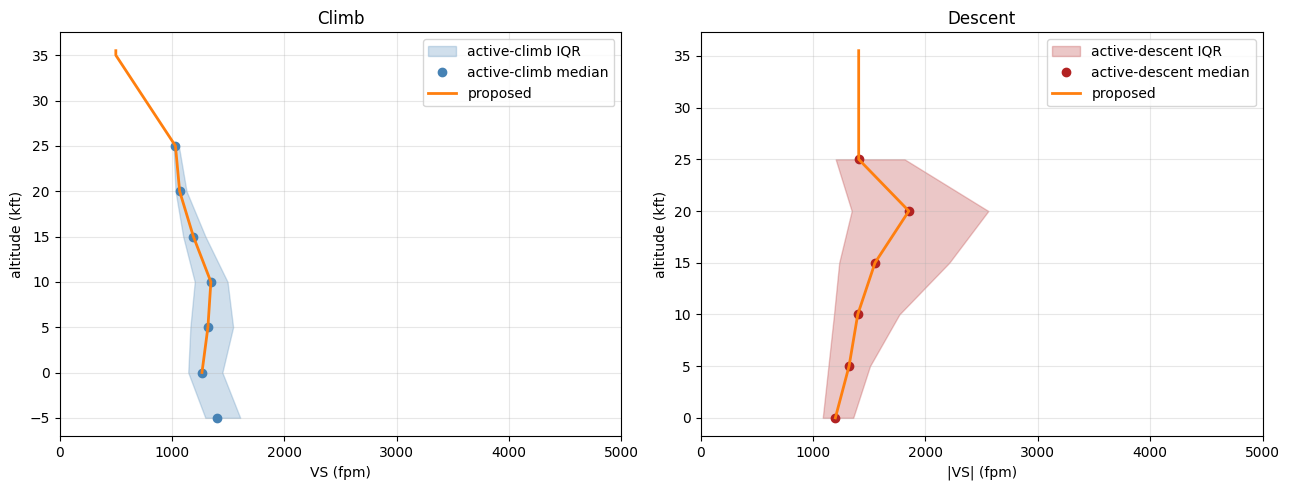

In [7]:
alt_grid = np.arange(0, 36000, 500)


def evaluate(points, alts):
    pts = sorted(points, key=lambda p: p[0])
    return np.interp(alts, [p[0] for p in pts], [p[1] for p in pts])


fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
ax.fill_betweenx(climb_bins["alt_bin_ft"]/1000,
                 climb_bins["vs_p25"], climb_bins["vs_p75"],
                 alpha=0.25, color="steelblue", label="active-climb IQR")
ax.plot(climb_bins["vs_med"], climb_bins["alt_bin_ft"]/1000,
        "o", color="steelblue", label="active-climb median")
ax.plot(evaluate(fixed, alt_grid), alt_grid/1000, color="C1", lw=2, label="proposed")
ax.set_xlabel("VS (fpm)"); ax.set_ylabel("altitude (kft)")
ax.set_title("Climb"); ax.legend(loc="upper right")
ax.grid(alpha=0.3); ax.set_xlim(0, 5000)

ax = axes[1]
ax.fill_betweenx(descent_bins["alt_bin_ft"]/1000,
                 (-descent_bins["vs_p75"]).abs(),
                 (-descent_bins["vs_p25"]).abs(),
                 alpha=0.25, color="firebrick", label="active-descent IQR")
ax.plot((-descent_bins["vs_med"]).abs(), descent_bins["alt_bin_ft"]/1000,
        "o", color="firebrick", label="active-descent median")
ax.plot(evaluate(fixed_desc, alt_grid), alt_grid/1000, color="C1", lw=2, label="proposed")
ax.set_xlabel("|VS| (fpm)"); ax.set_ylabel("altitude (kft)")
ax.set_title("Descent"); ax.legend(loc="upper right")
ax.grid(alpha=0.3); ax.set_xlim(0, 5000)
plt.tight_layout(); plt.show()


## 7. Bank, approach, peak altitude

In [8]:
banks = pd.concat([a["roll_deg"].abs() for a in sorties.values()]).dropna()
banks = banks[banks > 5.0]
print(f"|Roll| n={len(banks):,}, median {banks.median():.1f}°, p75 {banks.quantile(.75):.1f}°, p90 {banks.quantile(.90):.1f}°")

approach_tas = []
for a in sorties.values():
    floor = a["altitude"].min()
    sub = a[(a["altitude"] - floor < 500) & (a["altitude"] - floor > 50) & (a["vertical_rate"] < -200)]
    if not sub.empty and sub["tas_kt"].notna().any():
        approach_tas.append(sub["tas_kt"].median())
ap_s = pd.Series(approach_tas).dropna()
print(f"Approach TAS: n={len(ap_s)}, median {ap_s.median():.0f} kt, IQR {ap_s.quantile(.25):.0f}-{ap_s.quantile(.75):.0f}")

peaks = pd.Series([a["altitude"].max() for a in sorties.values()])
print(f"Peak alt: median {peaks.median():.0f} ft, p99 {peaks.quantile(0.99):.0f} ft, max {peaks.max():.0f} ft")


|Roll| n=1,137,070, median 16.5°, p75 24.2°, p90 30.0°


Approach TAS: n=160, median 113 kt, IQR 108-119
Peak alt: median 21293 ft, p99 30001 ft, max 30069 ft


## 8. Paste-ready KingAirB200 constructor

In [9]:
print("# Paste into hyplan/aircraft/_models.py KingAirB200.__init__")
print()
print("climb_profile=VerticalProfile(points=[")
for alt, vs in fixed:
    print(f"    ({alt:>5d} * ureg.feet, {vs:6.0f} * ureg.feet / ureg.minute),")
print("]),")
print()
print("descent_profile=VerticalProfile(points=[")
for alt, vs in fixed_desc:
    print(f"    ({alt:>5d} * ureg.feet, {vs:6.0f} * ureg.feet / ureg.minute),")
print("]),")
print()
print("climb_schedule=TasSchedule(points=[")
for alt, tas in climb_pts:
    print(f"    ({alt:>5d} * ureg.feet, {tas:3d} * ureg.knot),")
print("]),")
print()
print("cruise_schedule=TasSchedule(points=[")
for alt, tas in cruise_pts:
    print(f"    ({alt:>5d} * ureg.feet, {tas:3d} * ureg.knot),")
print("]),")
print()
print("descent_schedule=TasSchedule(points=[")
for alt, tas in descent_pts:
    print(f"    ({alt:>5d} * ureg.feet, {tas:3d} * ureg.knot),")
print("]),")
print()
print(f"approach_speed={int(round(ap_s.median()))} * ureg.knot,")
print(f"service_ceiling={int(round(peaks.quantile(0.99) / 1000) * 1000)} * ureg.feet,")
print(f"# AFM normal-ops 30°; data p90={banks.quantile(.90):.0f}°.")
print(f"turn_model=TurnModel(max_bank_deg=30.0),")


# Paste into hyplan/aircraft/_models.py KingAirB200.__init__

climb_profile=VerticalProfile(points=[
    (    0 * ureg.feet,   1267 * ureg.feet / ureg.minute),
    ( 5000 * ureg.feet,   1320 * ureg.feet / ureg.minute),
    (10000 * ureg.feet,   1346 * ureg.feet / ureg.minute),
    (15000 * ureg.feet,   1190 * ureg.feet / ureg.minute),
    (20000 * ureg.feet,   1068 * ureg.feet / ureg.minute),
    (25000 * ureg.feet,   1031 * ureg.feet / ureg.minute),
    (35000 * ureg.feet,    500 * ureg.feet / ureg.minute),
]),

descent_profile=VerticalProfile(points=[
    (    0 * ureg.feet,   1198 * ureg.feet / ureg.minute),
    ( 5000 * ureg.feet,   1320 * ureg.feet / ureg.minute),
    (10000 * ureg.feet,   1397 * ureg.feet / ureg.minute),
    (15000 * ureg.feet,   1551 * ureg.feet / ureg.minute),
    (20000 * ureg.feet,   1852 * ureg.feet / ureg.minute),
    (25000 * ureg.feet,   1406 * ureg.feet / ureg.minute),
]),

climb_schedule=TasSchedule(points=[
    (    0 * ureg.feet, 110 * ureg.knot),
   